# Load NFLVerse Play By Play Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
##import NflVerse Data

pbp = pd.read_csv(
    "https://github.com/nflverse/nflverse-data/releases/download/pbp/play_by_play_2025.csv.gz",
    compression="gzip"
)

pbp.head(10)

/var/folders/v9/6485yjr56hz28z9sx2l8lkq80000gn/T/ipykernel_82052/2435075317.py:3: DtypeWarning: Columns (0: two_point_conv_result, 1: lateral_receiver_player_id, 2: lateral_receiver_player_name, 3: lateral_rusher_player_id, 4: lateral_rusher_player_name, 5: lateral_interception_player_id, 6: lateral_interception_player_name, 7: own_kickoff_recovery_player_id, 8: own_kickoff_recovery_player_name, 9: blocked_player_id, 10: blocked_player_name, 11: forced_fumble_player_2_team, 12: forced_fumble_player_2_player_id, 13: forced_fumble_player_2_player_name, 14: solo_tackle_2_team, 15: solo_tackle_2_player_id, 16: solo_tackle_2_player_name, 17: assist_tackle_3_player_id, 18: assist_tackle_3_player_name, 19: assist_tackle_3_team, 20: assist_tackle_4_player_id, 21: assist_tackle_4_player_name, 22: assist_tackle_4_team, 23: fumbled_2_player_id, 24: fumbled_2_player_name, 25: fumbled_2_team, 26: fumble_recovery_2_team, 27: fumble_recovery_2_player_id, 28: fumble_recovery_2_player_name, 29: safety_

,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
0,1,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,NaN,NaN,NaN,...,0,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,40,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,-0.352700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,63,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,-0.190052,NaN,NaN,NaN,NaN,NaN,0.511128,-51.112807
3,85,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,1,0,1.317340,0.939998,4.750889,3.0,0.666726,0.439110,0.668940,33.105969
4,115,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,-1.694360,NaN,NaN,NaN,NaN,NaN,0.492038,50.796208
5,135,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,-1.284150,NaN,NaN,NaN,NaN,NaN,0.716846,-71.684569
6,166,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,-0.840574,NaN,NaN,NaN,NaN,NaN,0.756109,-75.610864
7,188,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,0.650589,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,214,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,NO,home,ARI,...,0,0,-0.194728,NaN,NaN,NaN,NaN,NaN,0.430873,-43.087283
9,243,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,NO,home,ARI,...,0,0,-0.788527,1.147553,5.786526,4.0,0.664423,0.453707,0.614372,38.562781


In [3]:
pbp.columns

Index(['play_id', 'game_id', 'old_game_id', 'home_team', 'away_team',
       'season_type', 'week', 'posteam', 'posteam_type', 'defteam',
       ...
       'out_of_bounds', 'home_opening_kickoff', 'qb_epa', 'xyac_epa',
       'xyac_mean_yardage', 'xyac_median_yardage', 'xyac_success', 'xyac_fd',
       'xpass', 'pass_oe'],
      dtype='str', length=372)

# Create Fourth Down Dataset

In [4]:
##Build fourth down df

fourth_downs = pbp[pbp['down'] == 4]
len(fourth_downs)

##Keep only 'go for it' attempts

go_for_it = fourth_downs[
    fourth_downs["play_type"].isin(["run", "pass"])
].copy()
len(go_for_it)
go_for_it.shape

(931, 372)

# Fourth Down Conversion Analytics

In [5]:
##Create our target variable

go_for_it["converted"] = (
    go_for_it["yards_gained"] >= go_for_it["ydstogo"]
).astype(int)

go_for_it[
    [
        "ydstogo",
        "yards_gained",
        "converted",
        "yardline_100",
        "score_differential"
    ]
].head(10)

,ydstogo,yards_gained,converted,yardline_100,score_differential
176,1,6.0,1,24.0,-7.0
180,10,0.0,0,18.0,-7.0
341,2,10.0,1,10.0,-15.0
378,1,4.0,1,63.0,0.0
471,1,0.0,0,5.0,-17.0
495,5,0.0,0,33.0,-17.0
504,1,3.0,1,34.0,17.0
567,1,2.0,1,48.0,-7.0
582,1,1.0,1,1.0,-7.0
664,5,0.0,0,39.0,-1.0


In [6]:
##How often do teams convert by distance?

conversion_rates = (
    go_for_it.groupby("ydstogo")["converted"]
    .mean()
    .round(2)
    .reset_index()

)

conversion_rates.head(10)

,ydstogo,converted
0,1,0.66
1,2,0.62
2,3,0.52
3,4,0.57
4,5,0.50
5,6,0.34
6,7,0.39
7,8,0.30
8,9,0.10
9,10,0.31


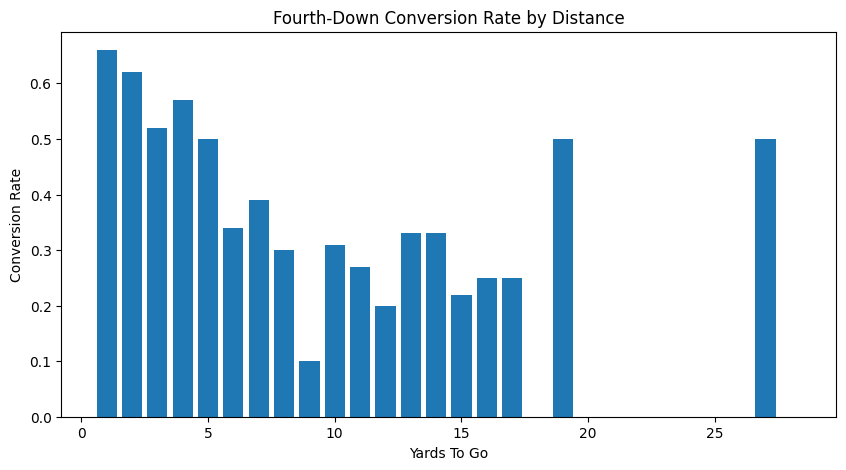

In [7]:
##Visualize our conversion data

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    conversion_rates["ydstogo"],
    conversion_rates["converted"]
)

plt.xlabel("Yards To Go")
plt.ylabel("Conversion Rate")
plt.title("Fourth-Down Conversion Rate by Distance")

plt.show()


The visualization above displays the fourth-down conversion rate by the distance required for a first down ('Yards To Go').

### Key Observations:
*   **Higher Conversion Rates for Shorter Distances:** As expected, teams show a higher propensity to convert fourth downs when the 'Yards To Go' is shorter, particularly within the 1-5 yard range. This aligns with typical strategic decisions in football.
*   **Anomalies at Longer Distances:** It's interesting to note the seemingly higher conversion rates at 18 and 27 yards to go, compared to the 5-15 yard range. While visually striking, these higher rates for longer distances (e.g., 18 and 27 yards) should be interpreted with caution. These attempts are likely much less frequent and may involve different play types or situations (e.g., Hail Mary passes, desperation plays) that don't represent a standard fourth-down attempt, thus skewing the conversion rate. The small sample size for these rare attempts can lead to volatile and potentially misleading conversion percentages.
*   **Decreasing Trend:** Generally, there's a clear decreasing trend in conversion rates as the 'Yards To Go' increases, indicating the increasing difficulty of converting longer distances.

In [8]:
conversion_summary = (
    go_for_it.groupby("ydstogo")
    .agg(
        attempts=("converted", "count"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

conversion_summary.head(20)

,ydstogo,attempts,conversion_rate
0,1,379,0.662269
1,2,136,0.625000
2,3,102,0.519608
3,4,82,0.573171
4,5,50,0.500000
5,6,38,0.342105
6,7,18,0.388889
7,8,27,0.296296
8,9,10,0.100000
9,10,32,0.312500


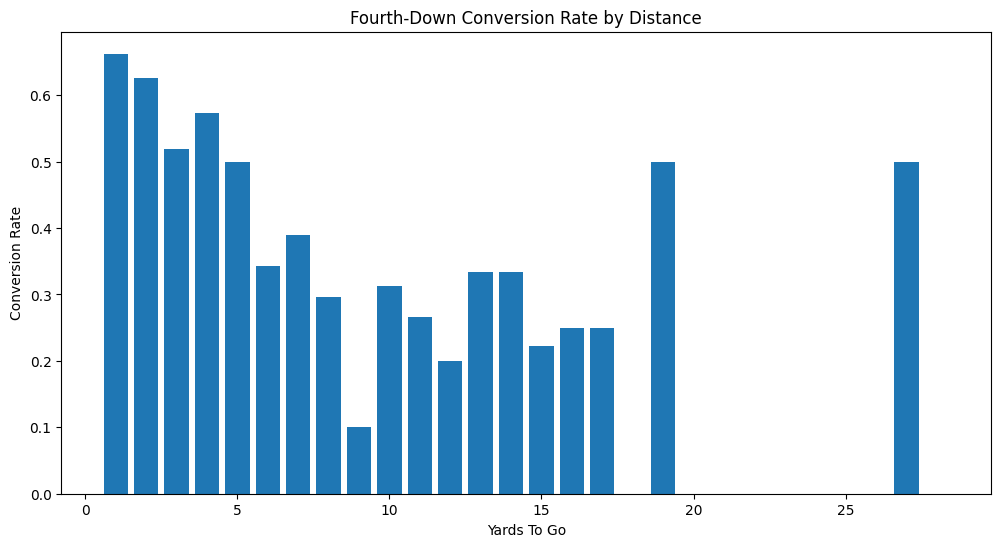

In [9]:
##New visualization

plt.figure(figsize=(12,6))

plt.bar(
    conversion_summary["ydstogo"],
    conversion_summary["conversion_rate"]
)

plt.xlabel("Yards To Go")
plt.ylabel("Conversion Rate")
plt.title("Fourth-Down Conversion Rate by Distance")

plt.show()

In [10]:
conversion_summary[
    conversion_summary["attempts"] >= 20
]

,ydstogo,attempts,conversion_rate
0,1,379,0.662269
1,2,136,0.625000
2,3,102,0.519608
3,4,82,0.573171
4,5,50,0.500000
5,6,38,0.342105
7,8,27,0.296296
9,10,32,0.312500


In [11]:
##Create zones of yards remaining to the endzone

go_for_it["field_zone"] = pd.cut(
    go_for_it["yardline_100"],
    bins=[0, 20, 50, 80, 100],
    labels=[
        "Red Zone",
        "Opponent Territory",
        "Midfield Area",
        "Own Territory"
    ]
)

##0-20 → close to scoring
##20-50 → opponent side
##50-80 → around midfield
##80-100 → backed up near own side

In [12]:
##Analyzing conversion rates by zone

zone_summary = (
    go_for_it.groupby("field_zone")
    .agg(
        attempts=("converted", "count"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

zone_summary

,field_zone,attempts,conversion_rate
0,Red Zone,258,0.573643
1,Opponent Territory,417,0.522782
2,Midfield Area,244,0.573770
3,Own Territory,12,0.666667


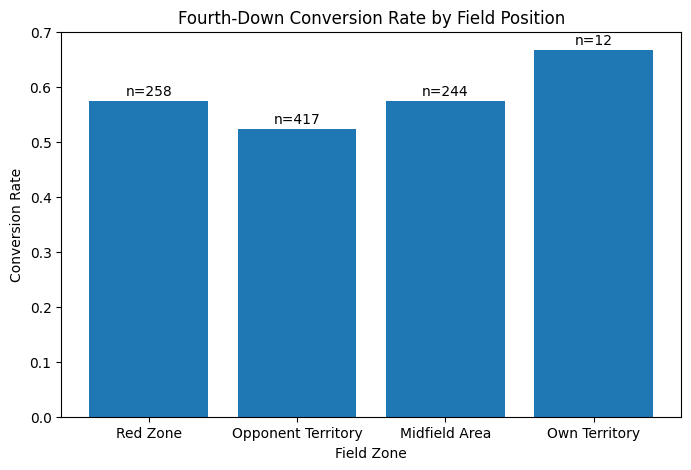

In [13]:
##Visualize

plt.figure(figsize=(8,5))

bars = plt.bar(
    zone_summary["field_zone"],
    zone_summary["conversion_rate"]
)

# Adding sample size labels
for bar, attempts in zip(bars, zone_summary["attempts"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"n={attempts}",
        ha='center'
    )

plt.ylabel("Conversion Rate")
plt.xlabel("Field Zone")
plt.title("Fourth-Down Conversion Rate by Field Position")

plt.show()

### Fourth-Down Conversion Rate by Field Position

The visualization above categorizes fourth-down attempts into four distinct field zones and shows their respective conversion rates along with the number of attempts (`n`).

#### Key Analytical Observations:

*   **Own Territory: High Efficiency, Low Volume:** The highest conversion rate is observed when teams attempt to convert a fourth down in their 'Own Territory' (66.7%). However, this also represents the smallest sample size with only 12 attempts. This suggests that coaches are extremely selective and likely only attempt these conversions in very favorable and high-confidence situations, or in desperate circumstances where the reward outweighs the risk.

*   **Red Zone vs. Midfield Area: Similar Effectiveness:** The 'Red Zone' and 'Midfield Area' show very similar conversion efficiencies, both hovering around 57%. This indicates that, despite the increased pressure and tighter defenses in the Red Zone, teams are converting fourth downs at a comparable rate to when they are around the middle of the field.

*   **Opponent Territory: Most Attempts, Lowest Rate:** 'Opponent Territory' sees the most fourth-down attempts (n=417) but surprisingly has the lowest conversion rate among all zones (52.3%). This suggests that while teams are most willing to 'go for it' on the opponent's side of the field, these situations are often more challenging than those selected in their own territory, or perhaps the yardage-to-go is frequently longer in these scenarios, contributing to a lower success rate. Additionally, the substantially larger sample size in Opponent Territory may provide a more statistically stable estimate of conversion efficiency compared to smaller-sample zones such as Own Territory. This aligns with the broader statistical principle that larger samples tend to produce more reliable estimates of underlying population behavior.

# Fourth Down Conversion Model

In [14]:
##Checking interaction between distance and field position

zone_distance_summary = (
    go_for_it.groupby(
        ["field_zone", "ydstogo"]
    )
    .agg(
        attempts=("converted", "count"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

In [15]:
##Filtering weak sample sizes

zone_distance_summary = zone_distance_summary[
    zone_distance_summary["attempts"] >= 10
]

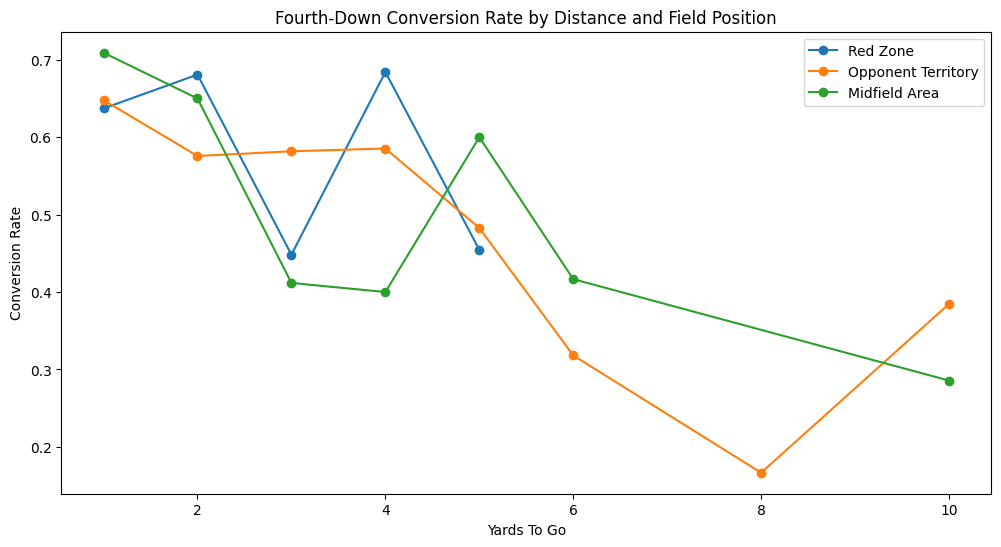

In [16]:
##Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for zone in zone_distance_summary["field_zone"].unique():

    zone_data = zone_distance_summary[
        zone_distance_summary["field_zone"] == zone
    ]

    plt.plot(
        zone_data["ydstogo"],
        zone_data["conversion_rate"],
        marker='o',
        label=zone
    )

plt.xlabel("Yards To Go")
plt.ylabel("Conversion Rate")
plt.title("Fourth-Down Conversion Rate by Distance and Field Position")

plt.legend()

plt.show()

### Fourth-Down Conversion Rate by Distance and Field Zone

The graph shows that fourth-down attempts in the Red Zone, Midfield Area, and Opponent Territory all have very high conversion rates when teams only need one or two yards. This is expected because shorter distances generally lead to higher success rates.

One interesting finding is that, after removing weak sample sizes, there is no Red Zone data for attempts needing more than five yards. This likely reflects teams' preference to leave the Red Zone with high-percentage points from a field goal instead of risking a turnover on downs.

The Red Zone conversion pattern follows a very similar shape to the Midfield Area pattern. The main difference is that teams appear more willing to attempt fourth downs from farther distances near midfield. This may be because teams feel safe enough to take a risk in that part of the field while also recognizing that a field goal is not yet a high-probability scoring opportunity.

Opponent Territory behaves differently from the other zones. Its conversion rate comes closest to a downward-sloping pattern as yards to go increases. One result that stands out is that Opponent Territory has the highest conversion rate at 10 yards compared with the other field zones, suggesting that longer fourth-down attempts in this area may occur in specific game situations where teams are more selective or more motivated to keep the drive alive.

In [17]:
##Create score bins

go_for_it["score_state"] = pd.cut(
    go_for_it["score_differential"],
    bins=[-100, -8, -1, 0, 7, 100],
    labels=[
        "Trailing by 8+",
        "Trailing by 1-7",
        "Tied",
        "Leading by 1-7",
        "Leading by 8+"
    ]
)

In [18]:
score_summary = (
    go_for_it.groupby("score_state")
    .agg(
        attempts=("converted", "count"),
        conversion_rate=("converted", "mean"),
        avg_yards_to_go=("ydstogo", "mean")
    )
    .reset_index()
)

score_summary

,score_state,attempts,conversion_rate,avg_yards_to_go
0,Trailing by 8+,344,0.468023,5.348837
1,Trailing by 1-7,267,0.565543,3.348315
2,Tied,128,0.632812,1.796875
3,Leading by 1-7,107,0.616822,2.037383
4,Leading by 8+,85,0.647059,2.270588


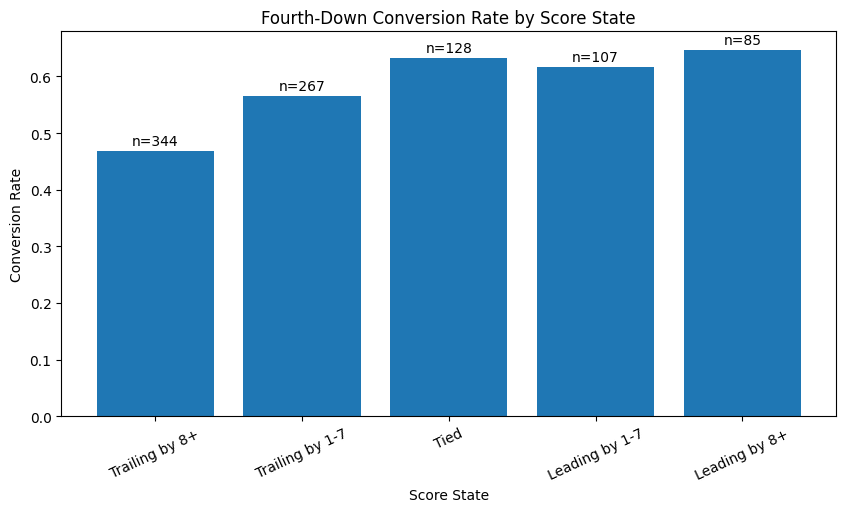

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

bars = plt.bar(
    score_summary["score_state"],
    score_summary["conversion_rate"]
)

for bar, attempts in zip(bars, score_summary["attempts"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"n={attempts}",
        ha="center"
    )

plt.ylabel("Conversion Rate")
plt.xlabel("Score State")
plt.title("Fourth-Down Conversion Rate by Score State")
plt.xticks(rotation=25)
plt.show()

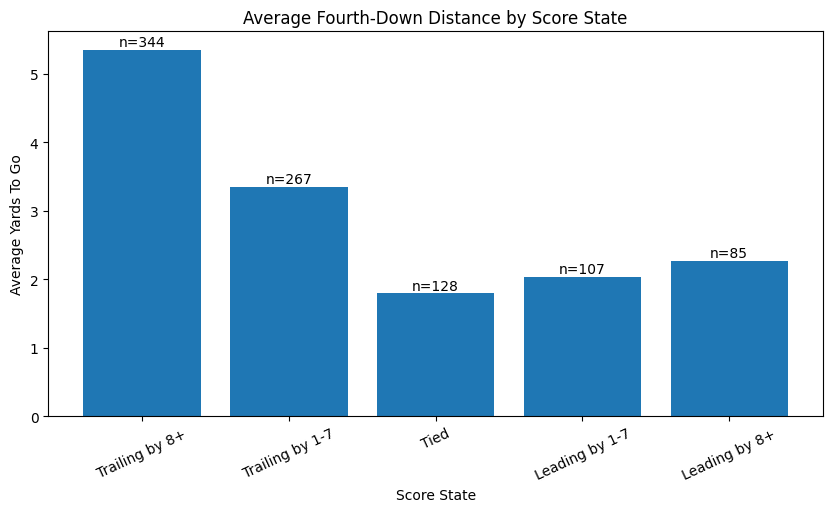

In [20]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    score_summary["score_state"],
    score_summary["avg_yards_to_go"]
)

for bar, attempts in zip(bars, score_summary["attempts"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"n={attempts}",
        ha="center"
    )

plt.ylabel("Average Yards To Go")
plt.xlabel("Score State")
plt.title("Average Fourth-Down Distance by Score State")
plt.xticks(rotation=25)
plt.show()

### Fourth-Down Conversion Rate by Score State

The fourth-down conversion rate by score state shows that teams trailing by more points tend to have lower conversion rates than teams in the opposite situation. Teams leading by 8 or more points have the highest conversion rate in this view. At the same time, the sample size buckets show an important pattern: the more a team is trailing by, the larger the sample size tends to be. This is most likely because trailing teams are more desperate to put points on the board instead of protecting field position from the opposing offense.

This also connects to the law of large numbers. The sample size for teams trailing by 8 or more points is more than four times larger than the sample size for teams leading by 8 or more points. That supports the idea that teams with large leads usually have less reason to risk a turnover on downs and are more likely to punt. One interesting pattern is that, according to the graph, the more a team is trailing by, the lower its conversion rate tends to be. The opposite also appears true: the more a team is winning by, the higher its conversion rate tends to be. However, before making absolute conclusions, we need to consider factors like sample size and why a team would choose to risk a turnover in each situation.

### Average Fourth-Down Distance by Score State

The average fourth-down distance by score state uses the same sample size buckets, but the graph tells a different story. It almost looks like an inverse of the conversion-rate graph. When teams are trailing by 8 or more points, they average more than five yards to go on fourth-down attempts. That number drops to a little over three yards to go when teams are trailing by 1 to 7 points.

Another interesting result is that the lowest average yards to go occurs when teams are tied, followed by teams leading by 1 to 7 points and then teams leading by 8 or more points. This is somewhat unexpected because we might assume that teams leading by 8 or more points would only go for it in very short-yardage situations. Like the previous graph, though, context matters. Smaller sample sizes can create more variance and less stable averages. Teams may also be less inclined to go for it on fourth down when the game is tied because they do not feel forced to take on extra risk. When teams are leading, some attempts may come in special situations where the winning team sees a chance to ice the game by converting a critical fourth down and keeping the game out of reach.

#Begin machine learning model using our findings as a basis

In [21]:
##Select features

## features = [
##    "ydstogo",
##    "yardline_100",
##    "score_differential"
##    "time remaining"
## ]

features = [
    "ydstogo",
    "yardline_100",
    "score_differential",
    "game_seconds_remaining"
]

X = go_for_it[features]

y = go_for_it["converted"]

In [22]:
##train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
##train a logistic regression model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [24]:
##Predict probabilities

y_probs = model.predict_proba(X_test)[:, 1]

In [25]:
##Evaluate model performance

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_probs)

print("ROC AUC:", round(auc, 3))

ROC AUC: 0.595


In [26]:
##inspect proabilities

results = X_test.copy()

results["actual"] = y_test.values
results["predicted_probability"] = y_probs

results.head(10)

,ydstogo,yardline_100,score_differential,game_seconds_remaining,actual,predicted_probability
43563,1,39.0,0.0,1826.0,0,0.673674
4090,6,66.0,-11.0,196.0,0,0.457746
33494,4,45.0,-11.0,2483.0,1,0.569008
27419,4,15.0,-13.0,122.0,0,0.454119
44407,1,56.0,2.0,1693.0,1,0.695559
5625,4,49.0,-3.0,1456.0,1,0.562516
25313,9,41.0,-3.0,1187.0,0,0.354133
4986,10,46.0,-14.0,79.0,0,0.279880
28509,1,47.0,7.0,2544.0,1,0.713477
19836,1,11.0,0.0,2577.0,1,0.656131


The predicted probabilities generally align with the football context explored earlier in the analysis. Variables such as yards to go, field position, score differential, and game time remaining all appear to contribute to the model’s estimated probability of converting a fourth down.

Shorter fourth-down distances tend to produce higher predicted conversion probabilities, which matches the earlier exploratory findings showing strong conversion success in short-yardage situations. Field position and score state also appear to influence predictions, helping explain why plays with similar distances may still receive different estimated probabilities depending on game context.

While the model captures several meaningful situational patterns, the overall ROC AUC score suggests that fourth-down conversion outcomes remain highly context-dependent and are influenced by additional factors not yet included in the model. This indicates that variables such as personnel, play design, defensive alignment, weather, and coaching tendencies may further improve predictive performance in future iterations.

######
Analyzing model coefficients


In [27]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients

,Feature,Coefficient
0,ydstogo,-0.154941
1,yardline_100,0.005868
2,score_differential,0.008390
3,game_seconds_remaining,0.000114


In [28]:
##Creating feature buckets due to poor coefficients

go_for_it["distance_bucket"] = pd.cut(
    go_for_it["ydstogo"],
    bins=[0, 2, 5, 100],
    labels=[
        "Short",
        "Medium",
        "Long"
    ]
)

In [29]:
##one hot encode our distance buckets

distance_dummies = pd.get_dummies(
    go_for_it["distance_bucket"],
    prefix="distance"
)

In [30]:
##Build new dataset with dummies

X = pd.concat(
    [
        go_for_it[
            [
                "yardline_100",
                "score_differential",
                "game_seconds_remaining"
            ]
        ],
        distance_dummies
    ],
    axis=1
)

In [31]:
y = go_for_it["converted"]

In [32]:
##train test split again

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
##train new logistic regression model

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [34]:
##predict probabilities again

y_probs = model.predict_proba(X_test)[:, 1]

In [35]:
##evalaute new model

auc = roc_auc_score(y_test, y_probs)

print("ROC AUC:", round(auc, 3))

ROC AUC: 0.593


In [36]:
##check new coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients

,Feature,Coefficient
0,yardline_100,0.004866
1,score_differential,0.008363
2,game_seconds_remaining,0.000119
3,distance_Short,0.557547
4,distance_Medium,0.058486
5,distance_Long,-0.842664


After replacing raw yards-to-go with distance buckets, the model became easier to interpret, but ROC AUC remained nearly unchanged. This suggests that distance category captures the same core signal as raw yards-to-go, while making the model’s football logic more explainable.

In [37]:
X = pd.concat(
    [
        go_for_it[
            [
                "ydstogo",
                "yardline_100",
                "score_differential",
                "game_seconds_remaining"
            ]
        ],
        distance_dummies
    ],
    axis=1
)

In [38]:
y = go_for_it["converted"]

In [39]:
##train test split again

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
##train new logistic regression model

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [41]:
##predict probabilities again

y_probs = model.predict_proba(X_test)[:, 1]

In [42]:
##evalaute new model

auc = roc_auc_score(y_test, y_probs)

print("ROC AUC:", round(auc, 3))

ROC AUC: 0.595


In [43]:
##check new coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients

,Feature,Coefficient
0,ydstogo,-0.082051
1,yardline_100,0.005739
2,score_differential,0.007593
3,game_seconds_remaining,0.000105
4,distance_Short,0.358953
5,distance_Medium,0.061681
6,distance_Long,-0.387869


distance buckets add interpretability, but not much new predictive information beyond raw yards-to-go. We need to continue feature engineering in order to train a better model before we move on to a new model. Lets begin by differentiating field zone position. Fourth and short in your own territory is vastly different than fourth and short in the end zone.

In [44]:
##Create interaction term between distance bucket and field zone

go_for_it["situation"] = (
    go_for_it["distance_bucket"].astype(str)
    + "_"
    + go_for_it["field_zone"].astype(str)
)

In [45]:
##One hot encode situation

situation_dummies = pd.get_dummies(
    go_for_it["situation"],
    prefix="situation"
)

In [46]:
##New feature matrix

X = pd.concat(
    [
        go_for_it[
            [
                "score_differential",
                "game_seconds_remaining"
            ]
        ],
        situation_dummies
    ],
    axis=1
)

In [53]:
y = go_for_it["converted"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_probs = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_probs)
print("ROC AUC:", round(auc, 3))

ROC AUC: 0.594


/Users/shri/Desktop/NFLFourthDownConversion/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [54]:
##Retrain model with new feature

X = pd.concat(
    [
        go_for_it[
            [
                "score_differential",
                "game_seconds_remaining"
            ]
        ],
        situation_dummies
    ],
    axis=1
)

In [55]:
##train logistic regression model

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/Users/shri/Desktop/NFLFourthDownConversion/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [56]:
##predict probabilities again x2

y_probs = model.predict_proba(X_test)[:, 1]

In [57]:
##Evaluate new model


auc = roc_auc_score(y_test, y_probs)

print("ROC AUC:", round(auc, 3))

ROC AUC: 0.594


In [58]:
##inspect new coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
10,situation_Short_Midfield Area,0.725449
11,situation_Short_Opponent Territory,0.559100
13,situation_Short_Red Zone,0.528395
8,situation_Medium_Own Territory,0.428423
9,situation_Medium_Red Zone,0.182763
7,situation_Medium_Opponent Territory,0.126615
12,situation_Short_Own Territory,0.074468
0,score_differential,0.007379
1,game_seconds_remaining,0.000128
2,situation_Long_Midfield Area,-0.173600


Fourth-down conversion probability is not driven solely by distance or field position independently, but rather by the interaction between the two. Short-yardage situations in midfield and opponent territory produce the strongest positive conversion signals, while long-yardage attempts, particularly in the Red Zone and Opponent Territory, are associated with substantially lower estimated conversion probabilities.